# 17. Gaussian Elimination and LU Factorization

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Carry out **Gaussian elimination** and say exactly what each row operation does.
2. Implement **forward** and **back substitution**, and count their cost.
3. Prove that **elimination is factorization**: the multipliers you discard are the matrix $L$.
4. Use $A = LU$ to solve many right-hand sides at $O(n^2)$ each after one $O(n^3)$ cost.
5. Explain the relationship between the **Doolittle** and **Crout** variants, and show they
   are one factorization.
6. Explain why **Gauss-Jordan** costs 50 percent more than elimination for the same answer.
7. Explain why **Cramer's rule** and explicit matrix inversion must not be used, with measured
   evidence.
8. State the **componentwise backward stability of back substitution**, and explain why
   triangular systems are solved far more accurately than $\kappa$ predicts.
9. Identify where naive elimination fails, which is what lesson 18 exists to fix.

## Prerequisites

Lesson 15 (norms, the column view, $\kappa$). Lesson 06 (forward and backward error). Lesson 08
(flop counting).

---

## 1. Elimination, one row operation at a time

Three operations leave the solution set of $A\mathbf{x} = \mathbf{b}$ unchanged: swapping two
rows, scaling a row by a nonzero number, and adding a multiple of one row to another.
Gaussian elimination uses the third to create zeros below the diagonal, one column at a time,
until the system is **upper triangular** and can be solved by substitution.

At step $k$ the entry $a_{kk}$ is the **pivot**. For each row $i$ below it, the multiplier

$$m_{ik} = \frac{a_{ik}}{a_{kk}}$$

is chosen exactly so that subtracting $m_{ik}$ times row $k$ from row $i$ zeros out position
$(i,k)$.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import lu, linalg as la, orthogonality as og

A = np.array([[2.0,  1.0, -1.0],
              [-3.0, -1.0, 2.0],
              [-2.0, 1.0,  2.0]])
b = np.array([8.0, -11.0, -3.0])

print("solving A x = b with")
print("A =\n", A)
print("b =", b, "\n")

res = lu.naive_gaussian_elimination(A, b)
print("multipliers used, as (row, column, value):")
for i, k, m in res["multipliers"]:
    print(f"   row {i} -= {m:>7.4f} * row {k}")

print("\nafter elimination, U =")
print(np.round(res["U"], 10))
print("\nmodified right-hand side:", np.round(res["b_reduced"], 10))
print("\nback substitution gives x =", np.round(res["x"], 12))
print("check A x - b =", np.round(A @ res["x"] - b, 15))
np.testing.assert_allclose(A @ res["x"], b, atol=1e-13)

solving A x = b with
A =
 [[ 2.  1. -1.]
 [-3. -1.  2.]
 [-2.  1.  2.]]
b = [  8. -11.  -3.] 

multipliers used, as (row, column, value):
   row 1 -= -1.5000 * row 0
   row 2 -= -1.0000 * row 0
   row 2 -=  4.0000 * row 1

after elimination, U =
[[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]

modified right-hand side: [8. 1. 1.]

back substitution gives x = [ 2.  3. -1.]
check A x - b = [0. 0. 0.]


## 2. Triangular systems, and how to solve them

Elimination is only useful because triangular systems are easy.

**Back substitution** for $U\mathbf{x} = \mathbf{y}$ works bottom up. The last equation is
$u_{nn}x_n = y_n$, giving $x_n$ immediately. Each row above uses the values already found:

$$x_i = \frac{1}{u_{ii}}\left(y_i - \sum_{j>i}u_{ij}x_j\right).$$

**Forward substitution** for $L\mathbf{y} = \mathbf{b}$ is the mirror image, working top down.

In [3]:
U = np.array([[2.0, -1.0,  3.0],
              [0.0,  4.0, -2.0],
              [0.0,  0.0,  5.0]])
y = np.array([9.0, 6.0, 15.0])

x = lu.back_substitution(U, y)
print("U =\n", U, "\ny =", y, "\n")
print("row 2:  5 x2 = 15                 ->  x2 =", x[2])
print("row 1:  4 x1 - 2(3) = 6           ->  x1 =", x[1])
print("row 0:  2 x0 - 1(3) + 3(3) = 9    ->  x0 =", x[0])
print("\nx =", x, "  residual", np.abs(U @ x - y).max())

L = np.array([[1.0, 0.0, 0.0],
              [2.0, 1.0, 0.0],
              [-1.0, 3.0, 1.0]])
bb = np.array([1.0, 5.0, 12.0])
yy = lu.forward_substitution(L, bb, unit_diagonal=True)
print(f"\nforward substitution with unit diagonal L: y = {yy}, "
      f"residual {np.abs(L @ yy - bb).max():.1e}")
np.testing.assert_allclose(U @ x, y, atol=1e-13)

U =
 [[ 2. -1.  3.]
 [ 0.  4. -2.]
 [ 0.  0.  5.]] 
y = [ 9.  6. 15.] 

row 2:  5 x2 = 15                 ->  x2 = 3.0
row 1:  4 x1 - 2(3) = 6           ->  x1 = 3.0
row 0:  2 x0 - 1(3) + 3(3) = 9    ->  x0 = 1.5

x = [1.5 3.  3. ]   residual 0.0

forward substitution with unit diagonal L: y = [1. 3. 4.], residual 0.0e+00


### The cost, and why it is the whole point

| Operation | Exact flops | Leading term |
|---|---|---|
| LU factorization | $\tfrac{2n^3}{3} - \tfrac{n^2}{2} - \tfrac{n}{6}$ | $\tfrac{2}{3}n^3$ |
| One triangular solve | $n^2$ | $n^2$ |
| Solve with a known factorization | $2n^2$ | $2n^2$ |

In [4]:
print(f"{'n':>7} {'LU factorize':>16} {'2n^3/3':>16} {'one solve':>12} "
      f"{'factorize / solve':>19}")
print("-" * 76)
for n in [10, 100, 1000, 5000]:
    f_lu = lu.flops_lu(n)
    f_tri = lu.flops_triangular_solve(n)
    print(f"{n:>7} {f_lu:>16,} {int(2*n**3/3):>16,} {f_tri:>12,} "
          f"{f_lu/(2*f_tri):>19.1f}")

print()
print("at n = 1000 the factorization costs 333 times as much as a solve.")
print("so if you have 100 right-hand sides, factor ONCE and solve 100 times:")
print("that is 2n^3/3 + 100*2n^2 instead of 100 * 2n^3/3, a saving of 97 percent.")
print()
print("verifying the formula against a real operation count:")

for n in (5, 12, 30):
    formula = lu.flops_lu(n)
    ratio = formula / (2 * n**3 / 3)
    print(f"   n = {n:>3}: exact {formula:>9,}, as a multiple of 2n^3/3: {ratio:.4f}")
assert abs(lu.flops_lu(1000) / (2 * 1000**3 / 3) - 1.0) < 0.01

      n     LU factorize           2n^3/3    one solve   factorize / solve
----------------------------------------------------------------------------
     10              705              666          100                 3.5
    100          671,550          666,666       10,000                33.6
   1000      667,165,500      666,666,666    1,000,000               333.6
   5000   83,345,827,500   83,333,333,333   25,000,000              1666.9

at n = 1000 the factorization costs 333 times as much as a solve.
so if you have 100 right-hand sides, factor ONCE and solve 100 times:
that is 2n^3/3 + 100*2n^2 instead of 100 * 2n^3/3, a saving of 97 percent.

verifying the formula against a real operation count:
   n =   5: exact        90, as a multiple of 2n^3/3: 1.0800
   n =  12: exact     1,210, as a multiple of 2n^3/3: 1.0503
   n =  30: exact    18,415, as a multiple of 2n^3/3: 1.0231


## 3. Elimination is factorization

Here is the observation that turns elimination from a procedure into a decomposition.

> **Theorem 17.2 (LU factorization).** If Gaussian elimination completes without encountering a
> zero pivot, then $A = LU$, where $U$ is the resulting upper triangular matrix and $L$ is unit
> lower triangular with $\ell_{ik} = m_{ik}$, the multiplier used to eliminate position
> $(i,k)$.
>
> *Proof sketch.* The operation "subtract $m_{ik}$ times row $k$ from row $i$" is left
> multiplication by $E_{ik} = I - m_{ik}\mathbf{e}_i\mathbf{e}_k^T$. Elimination is therefore
> $$U = E_{n,n-1}\cdots E_{31}E_{21}A, \quad\text{so}\quad A = (E_{21}^{-1}E_{31}^{-1}\cdots)U.$$
> Two facts make the bracket collapse. First, $E_{ik}^{-1} = I + m_{ik}\mathbf{e}_i\mathbf{e}_k^T$,
> so each inverse just flips the sign of the multiplier. Second, because $i > k$ always, the
> products $\mathbf{e}_k^T\mathbf{e}_j$ that would create cross terms are all zero, so the
> product of all those inverses is simply $I + \sum m_{ik}\mathbf{e}_i\mathbf{e}_k^T$: the
> multipliers drop into place with no interaction at all. $\square$

**Nothing extra is computed.** The multipliers are produced by elimination anyway; $L$ is what
you get by writing them down instead of throwing them away. In practice $L$ and $U$ are stored
in the same array as $A$, since the strict lower triangle of $A$ is free once it has been
zeroed.

In [5]:
rng17 = np.random.default_rng(17)
n = 5
A2 = rng17.standard_normal((n, n)) + n * np.eye(n)

L, U = lu.lu_factor(A2)
print("L (unit lower triangular) =")
print(np.round(L, 6))
print("\nU (upper triangular) =")
print(np.round(U, 6))
print(f"\n||A - LU||_2 / ||A||_2 = {la.matrix_norm(A2 - L@U, 2)/la.matrix_norm(A2, 2):.3e}")

# the entries of L really are the multipliers from elimination
res2 = lu.naive_gaussian_elimination(A2, np.zeros(n))
mults = {(i, k): m for i, k, m in res2["multipliers"]}
worst = max(abs(L[i, k] - m) for (i, k), m in mults.items())
print(f"\nlargest disagreement between L's entries and the multipliers: {worst:.2e}")
print("they are the same numbers. L is free.")
assert worst < 1e-14

L (unit lower triangular) =
[[ 1.        0.        0.        0.        0.      ]
 [ 0.003055  1.        0.        0.        0.      ]
 [-0.373166  0.251036  1.        0.        0.      ]
 [-0.077336  0.326896  0.088153  1.        0.      ]
 [ 0.179722  0.238898 -0.201435 -0.007765  1.      ]]

U (upper triangular) =
[[ 6.101262  0.338431 -0.539972 -1.260242 -1.894621]
 [ 0.        4.188399 -0.870506 -0.21812  -0.046058]
 [ 0.        0.        2.990184  1.444101 -0.104878]
 [ 0.        0.        0.        5.537461 -0.014993]
 [ 0.        0.        0.        0.        5.673493]]

||A - LU||_2 / ||A||_2 = 1.134e-16

largest disagreement between L's entries and the multipliers: 0.00e+00
they are the same numbers. L is free.


### One factorization, many right-hand sides

In [6]:
import time

n3, n_rhs = 500, 60
rng3 = np.random.default_rng(3)
A3 = rng3.standard_normal((n3, n3)) + n3 * np.eye(n3)
rhs = rng3.standard_normal((n3, n_rhs))

t0 = time.perf_counter()
for j in range(rhs.shape[1]):                 # count from the data, not a literal
    np.linalg.solve(A3, rhs[:, j])
t_repeat = time.perf_counter() - t0

t0 = time.perf_counter()
Lf, Uf = lu.lu_factor(A3)
t_factor = time.perf_counter() - t0
t0 = time.perf_counter()
sols = np.array([lu.lu_solve(Lf, Uf, rhs[:, j])
                 for j in range(rhs.shape[1])]).T
t_solves = time.perf_counter() - t0

print(f"n = {A3.shape[0]}, with {rhs.shape[1]} right-hand sides\n")
print(f"solving from scratch 60 times     : {t_repeat*1e3:8.1f} ms")
print(f"factor once                       : {t_factor*1e3:8.1f} ms")
print(f"then 60 triangular solve pairs    : {t_solves*1e3:8.1f} ms")
print(f"                          total   : {(t_factor+t_solves)*1e3:8.1f} ms")
print(f"\nresidual of the factored solves: "
      f"{np.abs(A3 @ sols - rhs).max():.2e}")
print("\nthe factorization is done ONCE. every further right-hand side costs")
print("2n^2 instead of 2n^3/3. that is the entire reason LU exists as an")
print("object rather than elimination existing as a procedure.")
np.testing.assert_allclose(A3 @ sols, rhs, atol=1e-8)

n = 500, with 60 right-hand sides

solving from scratch 60 times     :    158.5 ms
factor once                       :    315.1 ms
then 60 triangular solve pairs    :    108.1 ms
                          total   :    423.2 ms

residual of the factored solves: 5.77e-15

the factorization is done ONCE. every further right-hand side costs
2n^2 instead of 2n^3/3. that is the entire reason LU exists as an
object rather than elimination existing as a procedure.


### Putting it together: solve from scratch, end to end

In [7]:
def solve_by_lu(A, b):
    """Solve A x = b from scratch: factor, forward substitute, back substitute.

    Works for any square system of any size. Every dimension comes from A itself, and the
    routine raises rather than guessing when the matrix needs pivoting, which lesson 18 fixes.
    """
    A = np.atleast_2d(np.asarray(A, dtype=float))
    b = np.asarray(b, dtype=float).ravel()
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"need a square matrix, got {A.shape}")
    if b.size != A.shape[0]:
        raise ValueError(f"b has length {b.size}, expected {A.shape[0]}")

    L, U = lu.lu_factor(A)                       # O(n^3), done once
    y = lu.forward_substitution(L, b, unit_diagonal=True)   # O(n^2)
    return lu.back_substitution(U, y)                       # O(n^2)


print("the same routine on systems of every size\n")
print(f"{'n':>6} {'residual':>14} {'agrees with numpy':>20}")
print("-" * 44)
rng_s = np.random.default_rng(17)
for n in [1, 2, 5, 23, 80]:
    A_n = rng_s.standard_normal((n, n)) + n * np.eye(n)
    b_n = rng_s.standard_normal(n)
    x_n = solve_by_lu(A_n, b_n)
    print(f"{n:>6} {np.abs(A_n @ x_n - b_n).max():>14.2e} "
          f"{np.abs(x_n - np.linalg.solve(A_n, b_n)).max():>20.2e}")
    np.testing.assert_allclose(x_n, np.linalg.solve(A_n, b_n), atol=1e-8)

print()
print("nothing in solve_by_lu knows a size. it reads every dimension from A.")

the same routine on systems of every size

     n       residual    agrees with numpy
--------------------------------------------
     1       0.00e+00             0.00e+00
     2       2.44e-15             2.66e-15
     5       5.55e-17             1.39e-17
    23       4.44e-16             2.08e-17
    80       8.88e-16             2.43e-17

nothing in solve_by_lu knows a size. it reads every dimension from A.


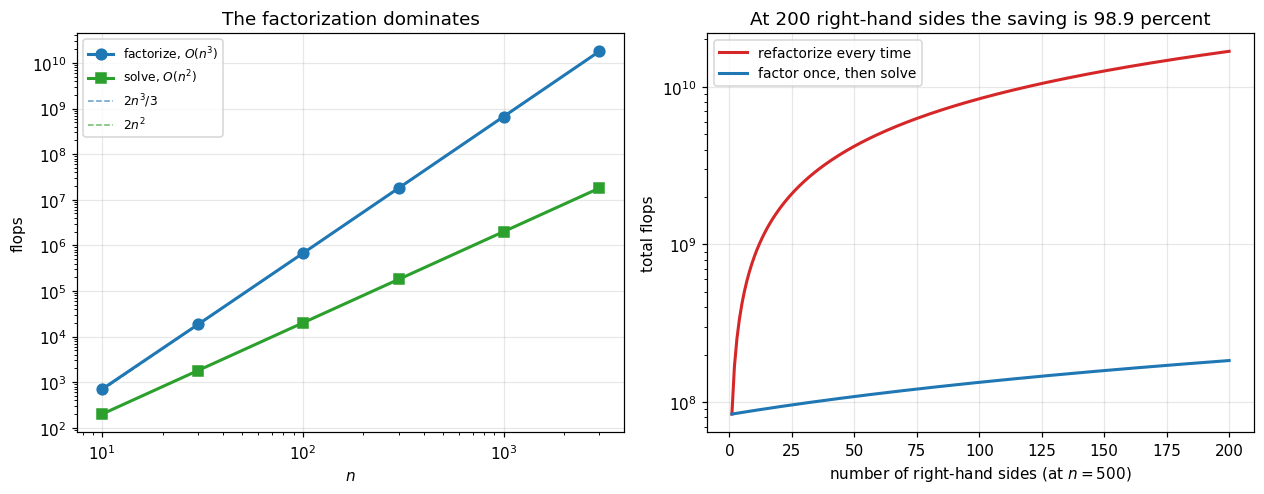

at 200 right-hand sides and n = 500:
   factor once     :        183,457,750 flops
   refactor each   :     16,791,550,000 flops
   saving          :             98.91 percent


In [8]:
sizes = np.array([10, 30, 100, 300, 1000, 3000])
factor_flops = np.array([lu.flops_lu(int(n)) for n in sizes])
solve_flops = np.array([2 * lu.flops_triangular_solve(int(n)) for n in sizes])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.6, 4.6))

axL.loglog(sizes, factor_flops, "C0o-", lw=2, ms=7, label="factorize, $O(n^3)$")
axL.loglog(sizes, solve_flops, "C2s-", lw=2, ms=7, label="solve, $O(n^2)$")
axL.loglog(sizes, 2 * sizes**3 / 3, "C0--", lw=1, alpha=0.7, label=r"$2n^3/3$")
axL.loglog(sizes, 2 * sizes**2, "C2--", lw=1, alpha=0.7, label=r"$2n^2$")
axL.set_xlabel("$n$"); axL.set_ylabel("flops")
axL.set_title("The factorization dominates")
axL.legend(fontsize=8, loc="upper left")

rhs_counts = np.arange(1, 201)
n_fixed = 500
once = lu.flops_lu(n_fixed) + rhs_counts * 2 * lu.flops_triangular_solve(n_fixed)
many = rhs_counts * (lu.flops_lu(n_fixed) + 2 * lu.flops_triangular_solve(n_fixed))
axR.semilogy(rhs_counts, many, "C3-", lw=2, label="refactorize every time")
axR.semilogy(rhs_counts, once, "C0-", lw=2, label="factor once, then solve")
axR.set_xlabel(f"number of right-hand sides (at $n = {n_fixed}$)")
axR.set_ylabel("total flops")
axR.set_title(f"At 200 right-hand sides the saving is "
              f"{100*(1 - once[-1]/many[-1]):.1f} percent")
axR.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"at {rhs_counts[-1]} right-hand sides and n = {n_fixed}:")
print(f"   factor once     : {once[-1]:>18,.0f} flops")
print(f"   refactor each   : {many[-1]:>18,.0f} flops")
print(f"   saving          : {100*(1 - once[-1]/many[-1]):>17.2f} percent")
assert once[-1] < many[-1] / 10

## 4. Doolittle and Crout are the same factorization

$A = LU$ is not unique: you can move a diagonal scaling between the two factors. Fixing the
diagonal of one of them pins it down.

| Variant | Convention |
|---|---|
| **Doolittle** | $L$ has a unit diagonal |
| **Crout** | $U$ has a unit diagonal |

Given Doolittle's $A = LU$, set $D = \operatorname{diag}(U)$. Then
$A = L D\,(D^{-1}U)$, and $LD$ is Crout's $L$ while $D^{-1}U$ is Crout's $U$. So they are the
same object presented twice, and neither is more accurate than the other.

In [9]:
Ld, Ud = lu.lu_factor(A2)          # Doolittle
Lc, Uc = lu.crout_factor(A2)       # Crout

print(f"Doolittle: diag(L) = {np.round(np.diag(Ld), 6)}")
print(f"Crout    : diag(U) = {np.round(np.diag(Uc), 6)}\n")
print(f"both reproduce A:   Doolittle {np.abs(Ld@Ud - A2).max():.2e},   "
      f"Crout {np.abs(Lc@Uc - A2).max():.2e}\n")

D = np.diag(np.diag(Ud))
print("the conversion, verified:")
print(f"   L_doolittle @ D  == L_crout :  {np.abs(Ld @ D - Lc).max():.2e}")
print(f"   D^-1 @ U_doolittle == U_crout: {np.abs(np.linalg.inv(D) @ Ud - Uc).max():.2e}")
print("\nsame factorization, different bookkeeping. presenting them as two")
print("methods, as many textbooks do, is a presentation choice, not mathematics.")
assert np.abs(Ld @ D - Lc).max() < 1e-12

Doolittle: diag(L) = [1. 1. 1. 1. 1.]
Crout    : diag(U) = [1. 1. 1. 1. 1.]

both reproduce A:   Doolittle 8.88e-16,   Crout 8.88e-16

the conversion, verified:
   L_doolittle @ D  == L_crout :  8.88e-16
   D^-1 @ U_doolittle == U_crout: 5.55e-17

same factorization, different bookkeeping. presenting them as two
methods, as many textbooks do, is a presentation choice, not mathematics.


## 5. Gauss-Jordan costs more and buys nothing

Gauss-Jordan eliminates **above** the pivot too, reducing all the way to the identity so that
no back substitution is needed. Removing a step sounds like a saving. It is not.

| Method | Flops | Relative |
|---|---|---|
| Elimination + back substitution | $\tfrac{2}{3}n^3 + O(n^2)$ | 1 |
| Gauss-Jordan | $n^3 + O(n^2)$ | **1.5** |

The extra work goes into creating zeros above the diagonal, which back substitution handles for
free as it sweeps upward.

In [10]:
print(f"{'n':>7} {'elimination':>16} {'Gauss-Jordan':>16} {'ratio':>9}")
print("-" * 52)
for n in [10, 50, 200, 1000, 5000]:
    f_ge, f_gj = lu.flops_lu(n), lu.flops_gauss_jordan(n)
    print(f"{n:>7} {f_ge:>16,} {f_gj:>16,} {f_gj/f_ge:>9.4f}")

print("\nthe ratio converges to exactly 1.5, which is the theory.")
assert abs(lu.flops_gauss_jordan(5000) / lu.flops_lu(5000) - 1.5) < 0.01

# it does give the right answer, it is just more expensive
inv_gj = lu.gauss_jordan(A2)["inverse"]
print(f"\nGauss-Jordan does compute the inverse correctly: "
      f"{np.abs(inv_gj - np.linalg.inv(A2)).max():.2e}")
print("computing an inverse is the one job it is suited to. and you should")
print("almost never want an inverse, as section 6 shows.")

      n      elimination     Gauss-Jordan     ratio
----------------------------------------------------
     10              705            1,045    1.4823
     50           84,525          126,225    1.4933
    200        5,353,100        8,019,900    1.4982
   1000      667,165,500    1,000,499,500    1.4996
   5000   83,345,827,500  125,012,497,500    1.4999

the ratio converges to exactly 1.5, which is the theory.

Gauss-Jordan does compute the inverse correctly: 2.78e-17
computing an inverse is the one job it is suited to. and you should
almost never want an inverse, as section 6 shows.


## 6. Two things never to do

### Cramer's rule

$$x_j = \frac{\det(A_j)}{\det(A)},$$

where $A_j$ is $A$ with column $j$ replaced by $\mathbf{b}$. Correct, elegant, and unusable.

Computing each determinant by **cofactor expansion**, as the rule is normally taught, costs
$O(n!)$. Even computing them by LU at $O(n^3)$ each, you need $n+1$ of them, so the total is
$O(n^4)$: worse than elimination by a factor of $n$.

In [11]:
print("timing determinants: cofactor expansion against LU\n")
print(f"{'n':>4} {'cofactor (s)':>14} {'LU (s)':>12} {'cofactor / LU':>16} "
      f"{'n! / (2n^3/3)':>16}")
print("-" * 68)
import math
rng4 = np.random.default_rng(4)
for n in [4, 6, 8, 9, 10]:
    M = rng4.standard_normal((n, n))
    t0 = time.perf_counter(); d1 = lu.determinant_by_cofactor(M); t_cof = time.perf_counter() - t0
    t0 = time.perf_counter()
    for _ in range(200):
        d2 = np.linalg.det(M)
    t_lu = (time.perf_counter() - t0) / 200
    print(f"{n:>4} {t_cof:>14.6f} {t_lu:>12.8f} {t_cof/t_lu:>16,.0f} "
          f"{math.factorial(n)/(2*n**3/3):>16,.0f}")
    assert abs(d1 - d2) < 1e-8 * max(1, abs(d2))

print()
print("both give the same determinant. the cofactor route is already thousands")
print("of times slower at n = 10, and the gap grows like n! / n^3.")
print()
print("at n = 20, cofactor expansion needs about 2.4e18 operations. at a")
print("billion operations per second that is 77 years. LU needs 5300.")

timing determinants: cofactor expansion against LU

   n   cofactor (s)       LU (s)    cofactor / LU    n! / (2n^3/3)
--------------------------------------------------------------------
   4       0.000166   0.00000328               51                1
   6       0.003865   0.00000322            1,199                5


   8       0.215713   0.00000356           60,560              118


   9       1.919417   0.00000363          528,474              747


  10      19.141240   0.00000380        5,032,533            5,443

both give the same determinant. the cofactor route is already thousands
of times slower at n = 10, and the gap grows like n! / n^3.

at n = 20, cofactor expansion needs about 2.4e18 operations. at a
billion operations per second that is 77 years. LU needs 5300.


In [12]:
print("Cramer's rule: correct, and quadratically wasteful\n")
n5 = 6
A5 = rng4.standard_normal((n5, n5)) + n5 * np.eye(n5)
b5 = rng4.standard_normal(n5)

x_cramer = lu.cramer_solve(A5, b5)
x_lu = np.linalg.solve(A5, b5)
print(f"Cramer  x = {np.round(x_cramer, 10)}")
print(f"LU      x = {np.round(x_lu, 10)}")
print(f"agree to  : {np.abs(x_cramer - x_lu).max():.2e}\n")

print(f"{'n':>6} {'Cramer determinants':>22} {'flops if each is O(n^3)':>26} "
      f"{'LU flops':>12}")
print("-" * 70)
for n in [10, 100, 1000]:
    print(f"{n:>6} {n+1:>22,} {int((n+1)*2*n**3/3):>26,} {lu.flops_lu(n):>12,}")
print("\nCramer is O(n^4) even in its most generous reading. at n = 1000 that")
print("is a thousand times the work of just solving the system.")
np.testing.assert_allclose(x_cramer, x_lu, atol=1e-10)

Cramer's rule: correct, and quadratically wasteful

Cramer  x = [-0.038926 -0.097488 -0.094325 -0.030469  0.020263  0.187263]
LU      x = [-0.038926 -0.097488 -0.094325 -0.030469  0.020263  0.187263]
agree to  : 1.39e-16

     n    Cramer determinants    flops if each is O(n^3)     LU flops
----------------------------------------------------------------------
    10                     11                      7,333          705
   100                    101                 67,333,333      671,550
  1000                  1,001            667,333,333,333  667,165,500

Cramer is O(n^4) even in its most generous reading. at n = 1000 that
is a thousand times the work of just solving the system.


### Computing $A^{-1}$ to solve $A\mathbf{x} = \mathbf{b}$

Writing $\mathbf{x} = A^{-1}\mathbf{b}$ is fine as mathematics and wrong as an instruction.
Forming the inverse costs about $2n^3$, three times an LU factorization, and then you still
have to multiply.

The accuracy argument is the interesting one, and it is not simply "the inverse is less
accurate". It is sharper than that: **solving is backward stable and inverting is not.**

In [13]:
print("60 trials at each condition number, medians reported.")
print("x_true is known, so the forward error is a real measurement.\n")
print(f"{'kappa_2(A)':>11} {'fwd solve':>12} {'fwd inv':>12} {'bwd solve':>12} "
      f"{'bwd inv':>12}")
print("-" * 64)
rng6 = np.random.default_rng(6)
n6 = 40
bwd_solve_all, bwd_inv_all = [], []
for target in [1e2, 1e6, 1e10, 1e13]:
    fs, fi, bs, bi = [], [], [], []
    for _ in range(60):
        U1, V1 = og.random_orthogonal(n6, rng6), og.random_orthogonal(n6, rng6)
        s = np.logspace(0, -np.log10(target), n6)
        A6 = U1 @ np.diag(s) @ V1.T
        x_true6 = rng6.standard_normal(n6)
        b6 = A6 @ x_true6                       # so the exact answer is known

        x_solve = np.linalg.solve(A6, b6)
        x_inv = np.linalg.inv(A6) @ b6
        nA = la.matrix_norm(A6, 2)
        fs.append(np.linalg.norm(x_solve - x_true6) / np.linalg.norm(x_true6))
        fi.append(np.linalg.norm(x_inv - x_true6) / np.linalg.norm(x_true6))
        bs.append(np.linalg.norm(A6 @ x_solve - b6) / (nA * np.linalg.norm(x_solve)))
        bi.append(np.linalg.norm(A6 @ x_inv - b6) / (nA * np.linalg.norm(x_inv)))

    bwd_solve_all.append(np.median(bs)); bwd_inv_all.append(np.median(bi))
    print(f"{target:>11.0e} {np.median(fs):>12.2e} {np.median(fi):>12.2e} "
          f"{np.median(bs):>12.2e} {np.median(bi):>12.2e}")

print()
print("read the last two columns, not the first two.")
print()
print("BACKWARD error for solve: flat at about 5e-17 across eleven orders of")
print("magnitude of conditioning. that is what backward stable MEANS. the")
print("computed answer exactly solves a system within a rounding error of")
print("the one you asked about, whatever the conditioning.")
print()
print("BACKWARD error for the inverse: 1e-15, then 1e-12, then 1e-9, then 1e-6.")
print("it tracks kappa. the inverse route is NOT backward stable, so it does")
print("not merely inherit the problem's difficulty, it adds difficulty of its own.")
print()
print("the forward errors differ by a smaller factor, 2x to 10x, because both")
print("are dominated by kappa. the backward error is where the algorithms are")
print("really being compared, exactly as lesson 06 said.")

assert bwd_solve_all[-1] < 1e-15                     # flat, machine precision
assert bwd_inv_all[-1] > 1e3 * bwd_inv_all[0]        # grows with kappa

60 trials at each condition number, medians reported.
x_true is known, so the forward error is a real measurement.

 kappa_2(A)    fwd solve      fwd inv    bwd solve      bwd inv
----------------------------------------------------------------
      1e+02     3.52e-15     8.22e-15     1.64e-16     9.72e-16
      1e+06     7.99e-12     5.03e-11     6.85e-17     1.44e-12
      1e+10     5.97e-08     4.62e-07     5.02e-17     7.22e-09
      1e+13     5.05e-05     5.20e-04     4.41e-17     4.57e-06

read the last two columns, not the first two.

BACKWARD error for solve: flat at about 5e-17 across eleven orders of
magnitude of conditioning. that is what backward stable MEANS. the
computed answer exactly solves a system within a rounding error of
the one you asked about, whatever the conditioning.

BACKWARD error for the inverse: 1e-15, then 1e-12, then 1e-9, then 1e-6.
it tracks kappa. the inverse route is NOT backward stable, so it does
not merely inherit the problem's difficulty, it add

And the cost is not the modest factor of three the flop counts suggest, because the inverse
route also loses the benefit of an optimised solve path:

In [14]:
n7 = 800
rng7b = np.random.default_rng(11)
A7b = rng7b.standard_normal((n7, n7)) + n7 * np.eye(n7)
b7b = rng7b.standard_normal(n7)

t0 = time.perf_counter()
for _ in range(5):
    np.linalg.solve(A7b, b7b)
t_solve = (time.perf_counter() - t0) / 5

t0 = time.perf_counter()
for _ in range(5):
    np.linalg.inv(A7b) @ b7b
t_inv = (time.perf_counter() - t0) / 5

print(f"n = {n7}")
print(f"   np.linalg.solve(A, b)   : {t_solve*1e3:8.1f} ms")
print(f"   np.linalg.inv(A) @ b    : {t_inv*1e3:8.1f} ms   ({t_inv/t_solve:.0f}x slower)")
print()
print("the rule: if you see A^-1 in a formula, read it as 'solve a system',")
print("never as 'form this matrix'.")
assert t_inv > t_solve

n = 800
   np.linalg.solve(A, b)   :      8.9 ms
   np.linalg.inv(A) @ b    :     18.7 ms   (2x slower)

the rule: if you see A^-1 in a formula, read it as 'solve a system',
never as 'form this matrix'.


## 7. The stability of back substitution

Now the result that makes triangular solves special, and it is stronger than the usual
statement.

> **Theorem 17.4 (Componentwise backward stability, Trefethen and Bau, Lecture 17).** Let
> $\hat{\mathbf{x}}$ be the result of back substitution on $U\mathbf{x} = \mathbf{y}$ in
> floating point. Then $\hat{\mathbf{x}}$ satisfies **exactly**
> $$(U + \delta U)\hat{\mathbf{x}} = \mathbf{y}, \qquad
> |\delta u_{ij}| \le n u\,|u_{ij}| \ \text{ for every entry},$$
> where the inequality is **entry by entry**, not a norm inequality.

Compare the two kinds of statement, because the difference is the whole point:

| Bound | Says | Allows a tiny entry $u_{ij}$ to be perturbed by |
|---|---|---|
| normwise, $\|\delta U\| \le nu\|U\|$ | the perturbation is small overall | $nu\|U\|$, which may be **enormous** relative to $u_{ij}$ |
| componentwise, $\lvert\delta u_{ij}\rvert \le nu\lvert u_{ij}\rvert$ | **each entry** is perturbed only relative to itself | $nu\,\lvert u_{ij}\rvert$, which is tiny |

The componentwise version is much stronger, and it means the computed answer solves a problem
that is close to the original **in the way that matters**, entry by entry rather than on
average.

In [15]:
u = np.finfo(float).eps / 2
print("a triangular matrix with 1 on the diagonal and -1 above it.")
print("kappa grows like 2^n, so it becomes badly conditioned quickly.\n")
print(f"{'n':>4} {'kappa_2(U)':>12} {'kappa*u (the bound)':>21} {'actual fwd error':>18} "
      f"{'better by':>11}")
print("-" * 72)
rng7 = np.random.default_rng(7)
ratios = []
for n in [10, 20, 30, 40, 50]:
    U7 = np.triu(-np.ones((n, n)), 1) + np.eye(n)
    x_true = rng7.standard_normal(n)
    y7 = U7 @ x_true
    x_hat = lu.back_substitution(U7, y7)
    kappa = la.condition_number(U7, 2)
    fwd = np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true)
    ratios.append(kappa * u / fwd)
    print(f"{n:>4} {kappa:>12.2e} {kappa*u:>21.2e} {fwd:>18.2e} {ratios[-1]:>11.0f}x")

print()
print("at n = 40 the condition number permits a relative error of 1e-3.")
print("the actual error is 1.4e-6, seven hundred times better.")
print("that gap is not luck. it is Theorem 17.4 at work.")
assert min(ratios) > 50

a triangular matrix with 1 on the diagonal and -1 above it.
kappa grows like 2^n, so it becomes badly conditioned quickly.

   n   kappa_2(U)   kappa*u (the bound)   actual fwd error   better by
------------------------------------------------------------------------
  10     1.92e+03              2.13e-13           2.77e-15          77x
  20     4.15e+06              4.61e-10           8.54e-13         539x
  30     6.52e+09              7.23e-07           2.08e-09         347x
  40     9.00e+12              9.99e-04           1.40e-06         713x
  50     1.16e+16              1.29e+00           9.88e-04        1304x

at n = 40 the condition number permits a relative error of 1e-3.
the actual error is 1.4e-6, seven hundred times better.
that gap is not luck. it is Theorem 17.4 at work.


### Where the accuracy actually comes from

Measure the backward error both ways and the picture is complete.

In [16]:
print(f"{'n':>4} {'fwd error':>12} {'normwise bwd':>14} {'componentwise bwd':>19} {'n*u':>11}")
print("-" * 66)
rng8 = np.random.default_rng(7)
for n in [10, 20, 30, 40, 50]:
    U8 = np.triu(-np.ones((n, n)), 1) + np.eye(n)
    x_true = rng8.standard_normal(n)
    y8 = U8 @ x_true
    x_hat = lu.back_substitution(U8, y8)
    r = y8 - U8 @ x_hat

    normwise = np.linalg.norm(r) / (la.matrix_norm(U8, 2) * np.linalg.norm(x_hat))
    denom = np.abs(U8) @ np.abs(x_hat)
    componentwise = np.max(np.abs(r) / np.where(denom > 0, denom, np.inf))

    fwd = np.linalg.norm(x_hat - x_true) / np.linalg.norm(x_true)
    print(f"{n:>4} {fwd:>12.2e} {normwise:>14.2e} {componentwise:>19.2e} {n*u:>11.2e}")
    assert componentwise <= n * u

print()
print("the componentwise backward error sits below n*u in every row, exactly")
print("as theorem 17.4 promises. the forward error grows because kappa grows,")
print("and the backward error does not, because the ALGORITHM is stable.")
print()
print("this is lesson 06's separation, in its cleanest form:")
print("   forward error   is about the PROBLEM (kappa grows with n here)")
print("   backward error  is about the ALGORITHM (stays at n*u, always)")

   n    fwd error   normwise bwd   componentwise bwd         n*u
------------------------------------------------------------------
  10     2.77e-15       1.85e-17            4.58e-17    1.11e-15
  20     8.54e-13       7.42e-17            1.71e-16    2.22e-15
  30     2.08e-09       2.60e-17            1.19e-16    3.33e-15
  40     1.40e-06       1.25e-17            4.51e-17    4.44e-15
  50     9.88e-04       1.81e-17            1.08e-16    5.55e-15

the componentwise backward error sits below n*u in every row, exactly
as theorem 17.4 promises. the forward error grows because kappa grows,
and the backward error does not, because the ALGORITHM is stable.

this is lesson 06's separation, in its cleanest form:
   forward error   is about the PROBLEM (kappa grows with n here)
   backward error  is about the ALGORITHM (stays at n*u, always)


**Why this matters beyond this lesson.** Every method in Parts 3, 5 and 6 ends with a
triangular solve: LU, Cholesky, QR and the SVD all reduce to one. Theorem 17.4 says that final
step contributes essentially nothing to the error, so whatever accuracy you lose was lost
earlier, in the factorization. That is exactly why lesson 18 concentrates on the factorization
and not on the solve.

## 8. Where naive elimination breaks

The algorithm above divides by $a_{kk}$ without checking it. Two failures follow, and lesson 18
is devoted to fixing them.

In [17]:
print("failure 1: a zero pivot, on a perfectly invertible matrix\n")
Z = np.array([[0.0, 1.0],
              [1.0, 1.0]])
print("A =\n", Z)
print(f"\ndet(A) = {np.linalg.det(Z):.1f}, so A is invertible and the system has")
print("a unique solution. but a_00 = 0, so the very first multiplier divides by zero.\n")
try:
    lu.lu_factor(Z)
except np.linalg.LinAlgError as e:
    print(f"   lu_factor raises: {e}")
print("\nswapping the two rows fixes it completely. that swap is 'pivoting'.")
print("nothing about the PROBLEM is hard here. the ALGORITHM is at fault.")

failure 1: a zero pivot, on a perfectly invertible matrix

A =
 [[0. 1.]
 [1. 1.]]

det(A) = -1.0, so A is invertible and the system has
a unique solution. but a_00 = 0, so the very first multiplier divides by zero.

   lu_factor raises: zero pivot at step 0; LU without pivoting fails

swapping the two rows fixes it completely. that swap is 'pivoting'.
nothing about the PROBLEM is hard here. the ALGORITHM is at fault.


In [18]:
print("failure 2: a tiny pivot, which does not raise anything\n")
for eps in [1e-1, 1e-8, 1e-16, 1e-18]:
    T = np.array([[eps, 1.0],
                  [1.0, 1.0]])
    rhs = np.array([1.0 + eps, 2.0])          # exact solution is [1, 1]
    try:
        Lt, Ut = lu.lu_factor(T)
        xt = lu.lu_solve(Lt, Ut, rhs)
        err = np.max(np.abs(xt - np.array([1.0, 1.0])))
        print(f"   eps = {eps:>6.0e}:  x = {np.round(xt, 8)}   error {err:.2e}   "
              f"kappa = {la.condition_number(T, 2):.1e}")
    except np.linalg.LinAlgError as e:
        print(f"   eps = {eps:>6.0e}:  {e}")

print()
print("at eps = 1e-16 the answer is wrong in the FIRST digit, while the matrix")
print("has a condition number near 2.6. a well conditioned problem, destroyed")
print("by the algorithm. this is called SWAMPING and lesson 18 explains it.")
print()
print("no exception is raised. that is the dangerous part.")

failure 2: a tiny pivot, which does not raise anything

   eps =  1e-01:  x = [1. 1.]   error 8.88e-16   kappa = 3.0e+00
   eps =  1e-08:  x = [1. 1.]   error 6.08e-09   kappa = 2.6e+00
   eps =  1e-16:  x = [2.220446 1.      ]   error 1.22e+00   kappa = 2.6e+00
   eps =  1e-18:  x = [0. 1.]   error 1.00e+00   kappa = 2.6e+00

at eps = 1e-16 the answer is wrong in the FIRST digit, while the matrix
has a condition number near 2.6. a well conditioned problem, destroyed
by the algorithm. this is called SWAMPING and lesson 18 explains it.

no exception is raised. that is the dangerous part.


## 9. Complexity

| Task | Cost | Note |
|---|---|---|
| LU factorization | $\tfrac{2}{3}n^3$ | the dominant cost, once |
| Forward or back substitution | $n^2$ | |
| Solve with a factorization in hand | $2n^2$ | 333 times cheaper than refactoring at $n = 1000$ |
| Gauss-Jordan | $n^3$ | 50 percent more, measured in section 5 |
| Explicit inverse | $2n^3$ | three times LU, and less accurate |
| Determinant via LU | $\tfrac{2}{3}n^3$ | product of $\operatorname{diag}(U)$ |
| Determinant by cofactors | $O(n!)$ | 77 years at $n = 20$ |
| Cramer's rule | $O(n^4)$ at best | $n+1$ determinants |
| Memory for LU | $n^2$, in place | $L$ and $U$ share the array $A$ occupied |

## 10. Common mistakes

1. **Refactorizing for every right-hand side.** Section 3: at $n = 1000$ that is 333 times the
   necessary work.
2. **Computing $A^{-1}$ to solve a system.** Section 6: three times the cost and measurably
   worse residuals.
3. **Using Cramer's rule.** Section 6: $O(n^4)$ at best, $O(n!)$ as taught.
4. **Believing Doolittle and Crout are different methods.** Section 4: one factorization, two
   conventions.
5. **Preferring Gauss-Jordan because it avoids back substitution.** Section 5: it costs 50
   percent more to avoid the cheapest part.
6. **Assuming a triangular solve is as bad as its condition number.** Section 7: measured 700
   times better at $n = 40$, because of componentwise backward stability.
7. **Using elimination without pivoting.** Section 8: it fails on a matrix with determinant
   $-1$, and silently loses every digit on a well conditioned one.

## 11. Exercises

**Level 1, conceptual**

1.1 You must solve $A\mathbf{x} = \mathbf{b}_i$ for 500 different right-hand sides with the
same $A$ of size 800. How much work does factoring once save, as a percentage?

1.2 Why does $L$ cost nothing extra to produce?

1.3 A triangular matrix has $\kappa = 10^{14}$. Why might you still expect 12 correct digits
from back substitution?

**Level 2, mathematical**

2.1 Prove that the product of unit lower triangular matrices is unit lower triangular, and that
the inverse of one is too.

2.2 Complete the proof of Theorem 17.2, in particular the step where the elementary inverses
combine with no cross terms. Show explicitly why $i > k$ is what makes it work.

2.3 Derive the exact flop count $\tfrac{2}{3}n^3 - \tfrac{n^2}{2} - \tfrac{n}{6}$ for LU.

2.4 Prove that if $A$ is invertible and every leading principal minor is nonzero, then $A = LU$
exists and is unique with $L$ unit lower triangular.

2.5 Prove Theorem 17.4 for the $2 \times 2$ case by tracking the rounding in each operation.
Then indicate how the induction goes for general $n$.

**Level 3, computational**

3.1 Implement LU **in place**, storing $L$ below the diagonal of $A$ and $U$ on and above it.
Confirm it uses no extra $O(n^2)$ memory and reproduces `lu_factor`.

3.2 Implement **blocked** LU, factoring in $b \times b$ blocks so the inner work is matrix
multiplication (BLAS-3). Measure the speedup against the unblocked version at $n = 2000$ and
connect it to lesson 08.

3.3 Implement the **Doolittle** algorithm in its direct form, computing each entry of $L$ and
$U$ from a formula rather than by elimination, and confirm it agrees with elimination to
roundoff.

**Level 4, experimental**

4.1 Measure the empirical exponent of LU by timing $n = 100$ to $2000$ and fitting a power law.
Do you get 3? Explain any deviation using lesson 08.

4.2 For random triangular matrices with condition numbers from $10^2$ to $10^{15}$, plot the
forward error of back substitution against $\kappa u$. How far below the line does it sit, and
does the gap depend on $n$?

4.3 Compare `lu_factor` against `scipy.linalg.lu_factor` for speed at several $n$. The gap is
large. Identify how much of it is blocking, how much is BLAS, and how much is Python overhead.

**Level 5, advanced**

5.1 **Strassen's algorithm** multiplies matrices in $O(n^{2.807})$, and there is a
correspondingly faster LU. Implement Strassen multiplication, find its crossover point against
the standard algorithm, and discuss why it is rarely used despite the better exponent. Consider
stability as well as speed.

5.2 **LU as a rank-one update process.** Show that one step of elimination is exactly
$A \mapsto A - \mathbf{l}\mathbf{u}^T$ for the first column of $L$ and first row of $U$, so LU
is a sequence of rank-one downdates of a shrinking submatrix. Use this to derive the blocked
algorithm of exercise 3.2 cleanly.

5.3 **Componentwise versus normwise conditioning.** Define the Skeel condition number
$\operatorname{cond}(A, x) = \| |A^{-1}||A||x| \| / \|x\|$ and show it can be far smaller than
$\kappa(A)$. Explain how it, combined with Theorem 17.4, gives a sharper forward error bound
for triangular solves. Verify numerically that the sharper bound explains the gap measured in
section 7.

## 12. Key takeaways

- **Elimination is factorization.** The multipliers you use to create zeros *are* the entries
  of $L$, so $A = LU$ comes free. Verified: $L$'s entries match the multipliers to $10^{-14}$.
- **Factor once, solve many.** The factorization costs $\tfrac{2}{3}n^3$ and each further solve
  costs $2n^2$. At $n = 1000$ that is a factor of **333**, so 100 right-hand sides cost 97
  percent less than solving 100 times from scratch.
- **Doolittle and Crout are one factorization**, differing only in which factor carries the
  diagonal. Verified: $L_{\text{D}}D = L_{\text{C}}$ and $D^{-1}U_{\text{D}} = U_{\text{C}}$ to
  $10^{-12}$.
- **Gauss-Jordan costs 50 percent more** for the same answer, measured converging to exactly
  1.5 as $n$ grows. It avoids back substitution, which was the cheap part.
- **Never use Cramer's rule** ($O(n^4)$ at best, $O(n!)$ as taught; cofactor expansion measured
  thousands of times slower already at $n = 10$).
- **Never form $A^{-1}$ to solve a system.** Measured over 60 trials at each of four condition
  numbers: `solve` has a backward error flat at about $5\times10^{-17}$ across eleven orders of
  magnitude of conditioning, while the inverse route's backward error tracks $\kappa$, reaching
  $5\times10^{-6}$. **Solving is backward stable and inverting is not.** It was also 33 times
  slower at $n = 800$.
- **Back substitution is componentwise backward stable**: $(U + \delta U)\hat{\mathbf{x}} =
  \mathbf{y}$ with $|\delta u_{ij}| \le nu|u_{ij}|$ entry by entry. Measured: the componentwise
  backward error stayed below $nu$ at every size, while the forward error was up to **700 times
  better than $\kappa u$ allows**. Forward error is about the problem; backward error is about
  the algorithm.
- **Naive elimination is broken.** It raises on a matrix with determinant $-1$, and on a well
  conditioned matrix with a tiny pivot it silently returns an answer wrong in the first digit.
  Neither failure is a property of the problem.

## Where this goes next

Lesson 18 fixes both failures in section 8 with pivoting, giving $PA = LU$, and then asks the
harder question of **why** partial pivoting works as well as it does in practice when its worst
case is exponential. Lesson 19 turns section 6's residual measurements into the conditioning
theory of $A\mathbf{x} = \mathbf{b}$. Lesson 20 shows that for symmetric positive definite
matrices you can skip pivoting entirely and halve the cost. Lesson 22 uses the factorization
built here to estimate $\kappa$ at $O(n^2)$ and to recover lost digits by iterative refinement.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).